In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("tables", exist_ok = True)
os.makedirs("figures", exist_ok = True)

In [2]:
#Numerical Methods:

def euler(f, t0, y0, h, n):

    t = np.linspace(t0, t0+n*h, n+1)

    y = np.zeros(n+1)
    y[0] = y0

    for i in range(n):
        y[i+1] = y[i] + h*f(t[i], y[i])

    return t, y

def midpoint(f, t0, y0, h, n):

    t = np.linspace(t0, t0+n*h, n+1)

    y = np.zeros(n+1)
    y[0] = y0

    for i in range(n):

        k1 = f(t[i], y[i])

        k2 = f(t[i] + h/2, y[i] + h*k1/2)

        y[i+1] = y[i] + h*k2

    return t, y

def heun(f, t0, y0, h, n):

    t = np.linspace(t0, t0+n*h, n+1)

    y = np.zeros(n+1)
    y[0] = y0

    for i in range(n):

        k1 = f(t[i], y[i])

        k2 = f(t[i] + h, y[i] + h*k1)

        y[i+1] = y[i] + h*(k1+k2)/2

    return t, y

def rk4(f, t0, y0, h, n):

    t = np.linspace(t0, t0+n*h, n+1)

    y = np.zeros(n+1)
    y[0] = y0

    for i in range(n):

        k1 = f(t[i], y[i])

        k2 = f(t[i] + h/2, y[i] + h * k1/2)

        k3 = f(t[i]+h/2, y[i]+h*k2/2)

        k4 = f(t[i]+h, y[i]+h*k3)

        y[i+1] = y[i] + h*(k1+2*k2+2*k3+k4)/6

    return t, y

def taylor2_A(t0, y0, h, n):

    t = np.linspace(t0, t0+n*h, n+1)

    y = np.zeros(n+1)
    y[0] = y0

    for i in range(n):

        f = y[i] - t[i]**2 + 1
        y2 = f - 2*t[i]

        y[i+1] = y[i] + h*f + (h**2/2)*y2

    return t, y

def taylor2_B(t0, y0, h, n):

    t = np.linspace(t0, t0+n*h, n+1)

    y = np.zeros(n+1)
    y[0] = y0

    for i in range(n):

        f = 2*y[i]
        y2 = 4*y[i]

        y[i+1] = y[i] + h*f + (h**2/2)*y2

    return t, y

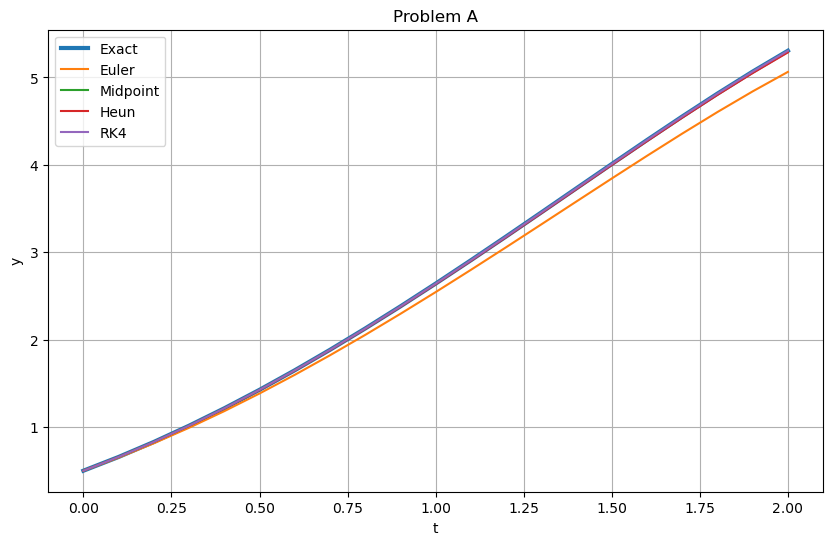

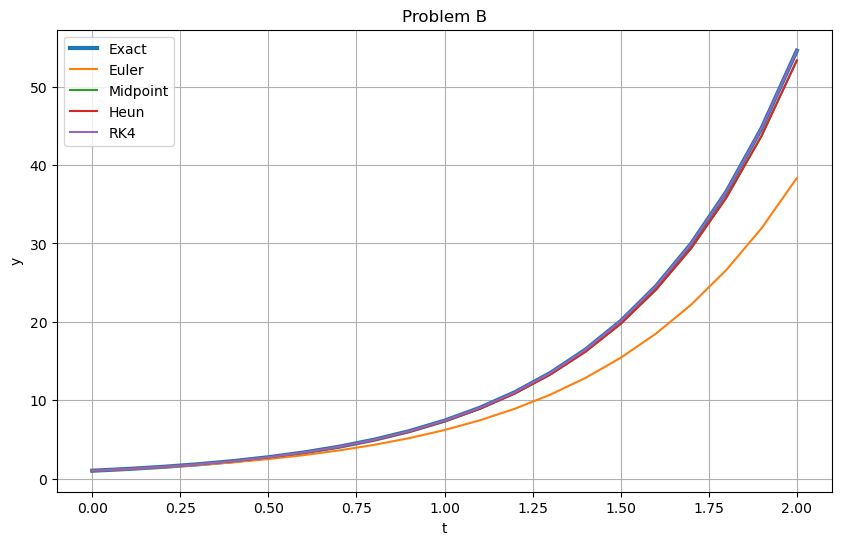

In [3]:
#Problem A:

fA = lambda t,y: y - t**2 + 1
exactA = lambda t: (t+1)**2 - 0.5*np.exp(t)

h = 0.1
t0 = 0
y0 = 0.5
end = 2

n = int((end-t0)/h)

t = np.linspace(t0,end,n+1)

y_exact = exactA(t)

_, y_euler = euler(fA,t0,y0,h,n)
_, y_mid = midpoint(fA,t0,y0,h,n)
_, y_heun = heun(fA,t0,y0,h,n)
_, y_rk4 = rk4(fA,t0,y0,h,n)

tableA = pd.DataFrame({"t":t, "Exact":y_exact, "Euler":y_euler, "Midpoint":y_mid, "Heun":y_heun, "RK4":y_rk4})

tableA.to_csv("tables/problem_a_table.csv", index = False)

plt.figure(figsize = (10,6))

plt.plot(t,y_exact,label = "Exact",linewidth = 3)
plt.plot(t,y_euler,label = "Euler")
plt.plot(t,y_mid,label = "Midpoint")
plt.plot(t,y_heun,label = "Heun")
plt.plot(t,y_rk4,label = "RK4")

plt.title("Problem A")
plt.xlabel("t")
plt.ylabel("y")
plt.legend()
plt.grid()

plt.savefig("figures/problem_a_graph.png", dpi = 300)

plt.show()


#Problem B:

fB = lambda t,y: 2*y
exactB = lambda t: np.exp(2*t)

t = np.linspace(0,2,n+1)

y_exact = exactB(t)

_, y_euler = euler(fB,0,1,h,n)
_, y_mid = midpoint(fB,0,1,h,n)
_, y_heun = heun(fB,0,1,h,n)
_, y_rk4 = rk4(fB,0,1,h,n)

tableB = pd.DataFrame({"t":t, "Exact":y_exact, "Euler":y_euler, "Midpoint":y_mid, "Heun":y_heun, "RK4":y_rk4})

tableB.to_csv("tables/problem_b_table.csv", index = False)

plt.figure(figsize = (10,6))

plt.plot(t,y_exact,label = "Exact",linewidth = 3)
plt.plot(t,y_euler,label = "Euler")
plt.plot(t,y_mid,label = "Midpoint")
plt.plot(t,y_heun,label = "Heun")
plt.plot(t,y_rk4,label = "RK4")

plt.title("Problem B")
plt.xlabel("t")
plt.ylabel("y")
plt.legend()
plt.grid()

plt.savefig("figures/problem_b_graph.png", dpi = 300)

plt.show()

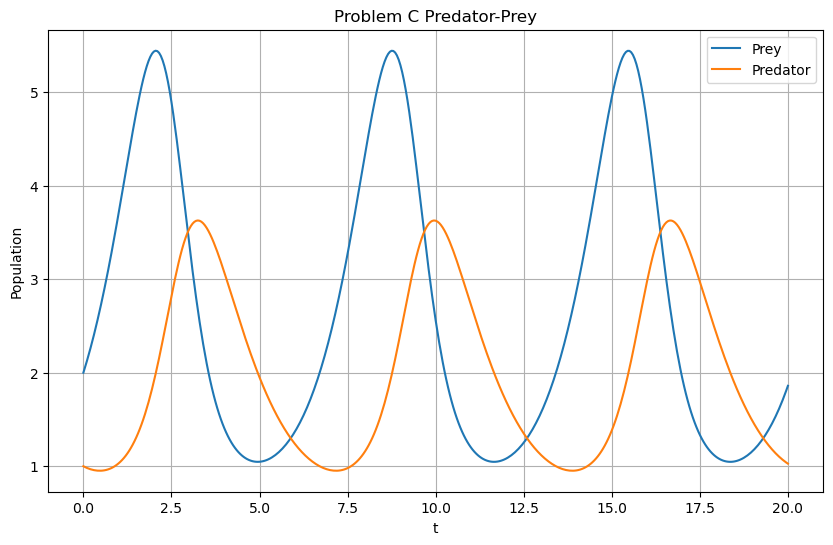

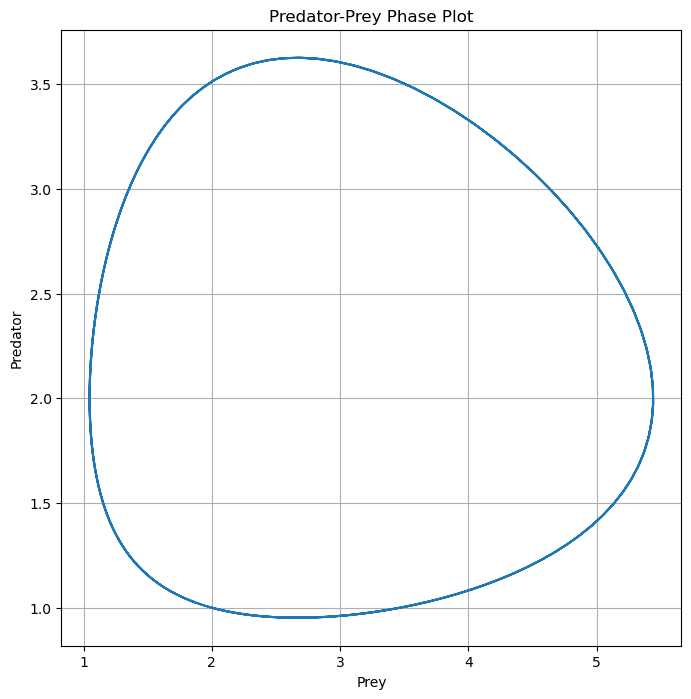

In [4]:
#Problem C:

def predator_prey(t, Y):

    x = Y[0]
    y = Y[1]

    dx = 1.2*x - 0.6*x*y
    dy = -0.8*y + 0.3*x*y

    return np.array([dx,dy])

def rk4_system(f,t0,y0,h,n):

    t = np.linspace(t0,t0+n*h,n+1)

    y = np.zeros((n+1, len(y0)))
    y[0] = y0

    for i in range(n):

        k1 = f(t[i],y[i])

        k2 = f(t[i]+h/2, y[i]+h*k1/2)

        k3 = f(t[i]+h/2, y[i]+h*k2/2)

        k4 = f(t[i]+h, y[i]+h*k3)

        y[i+1] = y[i] + h*(k1+2*k2+2*k3+k4)/6

    return t,y

t0 = 0
end = 20
h = 0.05

n = int((end-t0)/h)

y0 = np.array([2,1])

t, sol = rk4_system(predator_prey, t0, y0, h, n)

x = sol[:,0]
y = sol[:,1]

tableC = pd.DataFrame({"t":t, "Prey":x, "Predator":y})

tableC.to_csv("tables/problem_c_table.csv", index = False)

plt.figure(figsize = (10,6))

plt.plot(t, x, label = "Prey")

plt.plot(t, y, label = "Predator")

plt.title("Problem C Predator-Prey")
plt.xlabel("t")
plt.ylabel("Population")
plt.legend()
plt.grid()

plt.savefig("figures/problem_c_graph.png", dpi=300)

plt.show()

plt.figure(figsize = (8,8))

plt.plot(x,y)

plt.title("Predator-Prey Phase Plot")
plt.xlabel("Prey")
plt.ylabel("Predator")
plt.grid()

plt.savefig("figures/problem_c_phase_graph.png", dpi = 300)

plt.show()

In [5]:
#This is to export the numerical results to LaTex tables

tableA.to_latex("problem_a_table.tex", index = False, float_format = "%.6f")

tableB.to_latex("problem_b_table.tex", index = False, float_format = "%.6f")

tableC.to_latex("problem_c_table.tex", index = False, float_format = "%.6f")

In [6]:
#This is to create a condensed table to be shown under Problem C. The table is split into two halves to be shown side-by-side in my report.

tableC_display = tableC.iloc[::20]

mid = len(tableC_display) // 2

tableC_left = tableC_display.iloc[:mid]
tableC_right = tableC_display.iloc[mid:]

tableC_left.to_latex("problem_c_table_left.tex", index = False, float_format="%.6f")

tableC_right.to_latex("problem_c_table_right.tex", index = False, float_format="%.6f")